# Matplotlib Histogram Examples with Khisto

This notebook demonstrates the matplotlib histogram plotting functionality using Khisto's optimal binning algorithm.

In [23]:
import os

os.environ["KHISTO_BIN_DIR"] = (
    "/home/elouen/python/khisto-python/src/khiops/build/linux-gcc-debug/bin/khisto"
)

import numpy as np
import matplotlib.pyplot as plt
from khisto.matplotlib import histogram, cumulative

# Set random seed for reproducibility
np.random.seed(42)

## 1. Basic Histogram

Create a simple histogram from a NumPy array with normal distribution.

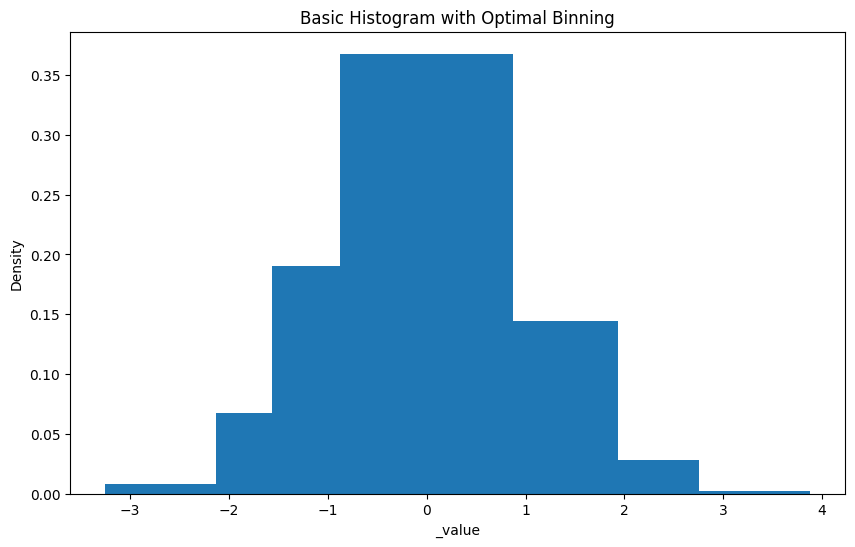

In [24]:
# Generate sample data
data = np.random.normal(0, 1, 1000)

# Create histogram
fig, ax = plt.subplots(figsize=(10, 6))
histogram(x=data, ax=ax, title="Basic Histogram with Optimal Binning")
plt.show()

## 2. Horizontal Histogram

Demonstrate horizontal orientation for the histogram.

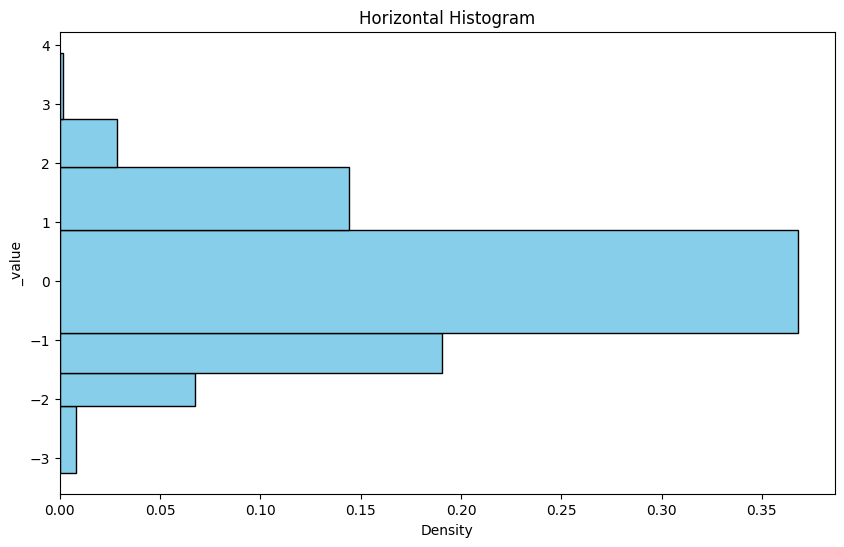

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))
histogram(
    x=data,
    ax=ax,
    orientation="horizontal",
    title="Horizontal Histogram",
    color="skyblue",
    edgecolor="black",
)
plt.show()

## 3. Cumulative Distribution Function (CDF)

Show cumulative probability distribution using the dedicated `cumulative` function.

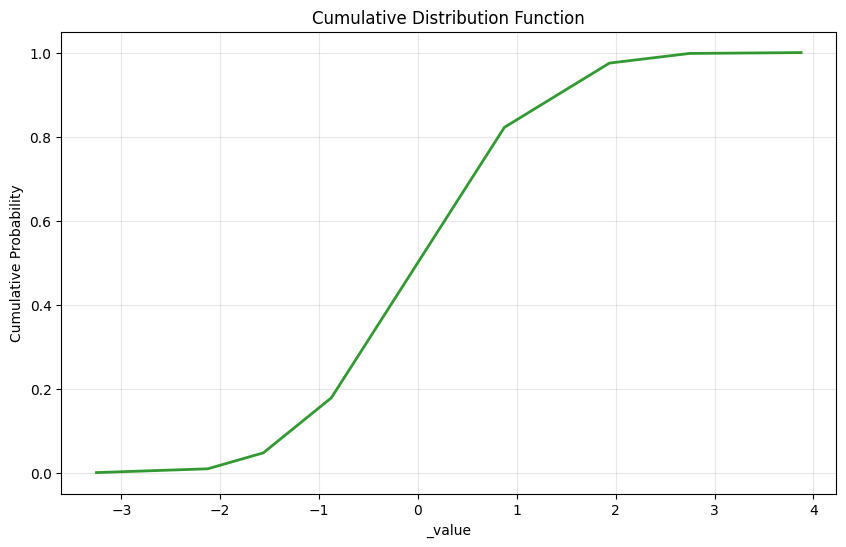

In [26]:
fig, ax = plt.subplots(figsize=(10, 6))
cumulative(
    x=data,
    ax=ax,
    title="Cumulative Distribution Function",
    color="green",
    linewidth=2,
    alpha=0.8,
)
plt.grid(alpha=0.3)
plt.show()

## 4. Histogram with Custom Styling

Demonstrate various styling options available.

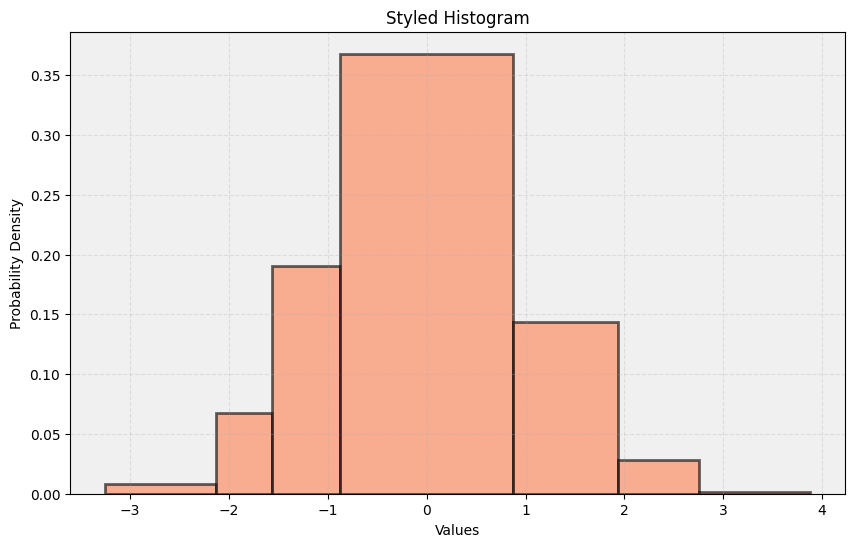

In [27]:
fig, ax = plt.subplots(figsize=(10, 6))
histogram(
    x=data,
    ax=ax,
    title="Styled Histogram",
    xlabel="Values",
    ylabel="Probability Density",
    color="coral",
    alpha=0.6,
    edgecolor="black",
    linewidth=2,
)
ax.set_facecolor("#f0f0f0")
plt.grid(alpha=0.3, linestyle="--")
plt.show()

## 5. Using with Pandas DataFrame

Create histograms from DataFrame columns.

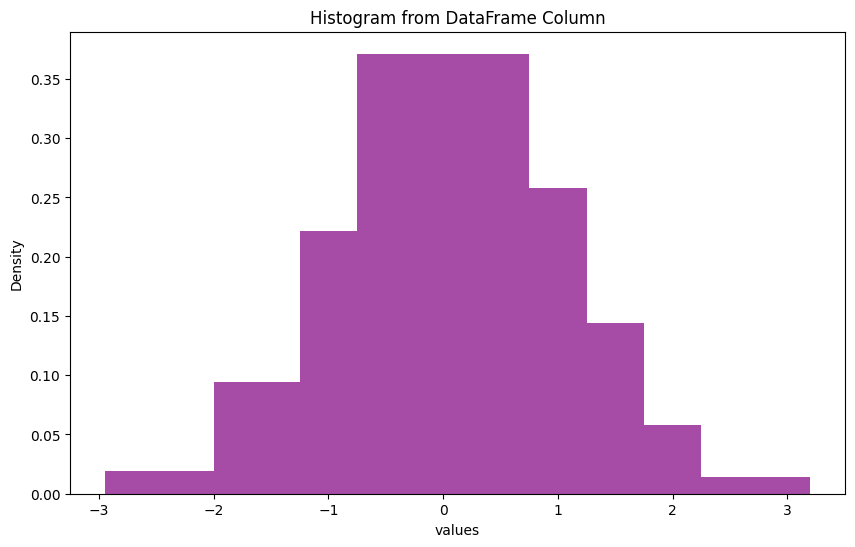

In [28]:
import pandas as pd

# Create a DataFrame
df = pd.DataFrame(
    {
        "values": np.random.normal(0, 1, 1000),
        "category": np.random.choice(["A", "B", "C"], 1000),
    }
)

fig, ax = plt.subplots(figsize=(10, 6))
histogram(
    data=df,
    x="values",
    ax=ax,
    title="Histogram from DataFrame Column",
    color="purple",
    alpha=0.7,
)
plt.show()

## 6. Grouped Histogram with Hue

Create separate histograms for different groups using the `hue` parameter.

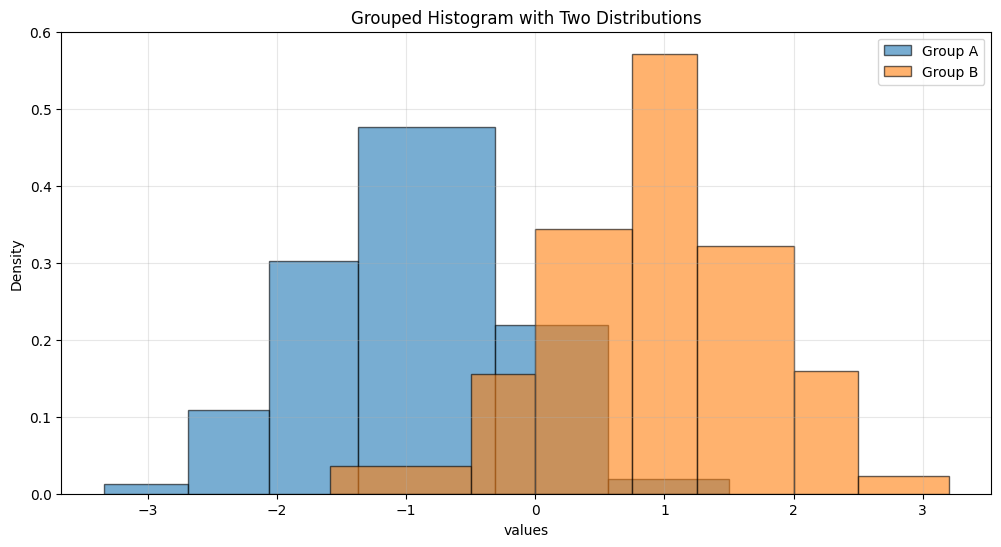

In [29]:
# Create DataFrame with groups
df_groups = pd.DataFrame(
    {
        "values": np.concatenate(
            [np.random.normal(-1, 0.8, 500), np.random.normal(1, 0.8, 500)]
        ),
        "group": ["Group A"] * 500 + ["Group B"] * 500,
    }
)

fig, ax = plt.subplots(figsize=(12, 6))
histogram(
    data=df_groups,
    x="values",
    hue="group",
    ax=ax,
    title="Grouped Histogram with Two Distributions",
    alpha=0.6,
    edgecolor="black",
)
plt.grid(alpha=0.3)
plt.show()

## 7. Comparison with Multiple Categories

Compare distributions across multiple categories.

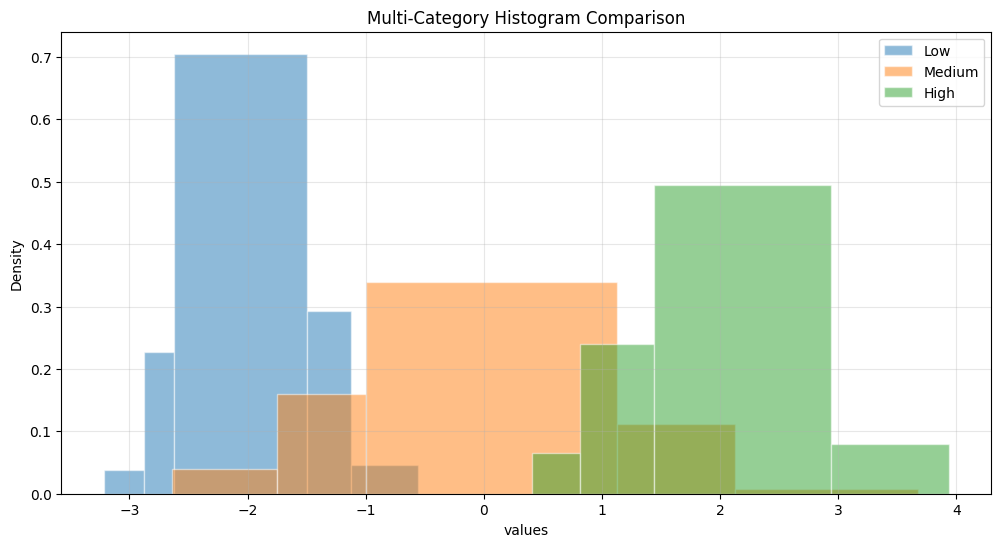

In [30]:
# Create DataFrame with multiple categories
df_multi = pd.DataFrame(
    {
        "values": np.concatenate(
            [
                np.random.normal(-2, 0.5, 300),
                np.random.normal(0, 1, 400),
                np.random.normal(2, 0.7, 300),
            ]
        ),
        "category": ["Low"] * 300 + ["Medium"] * 400 + ["High"] * 300,
    }
)

fig, ax = plt.subplots(figsize=(12, 6))
histogram(
    data=df_multi,
    x="values",
    hue="category",
    ax=ax,
    title="Multi-Category Histogram Comparison",
    alpha=0.5,
    edgecolor="white",
    linewidth=1,
)
plt.grid(alpha=0.3)
plt.show()

## 8. Subplot Grid

Use histograms in a subplot grid to compare different distributions.

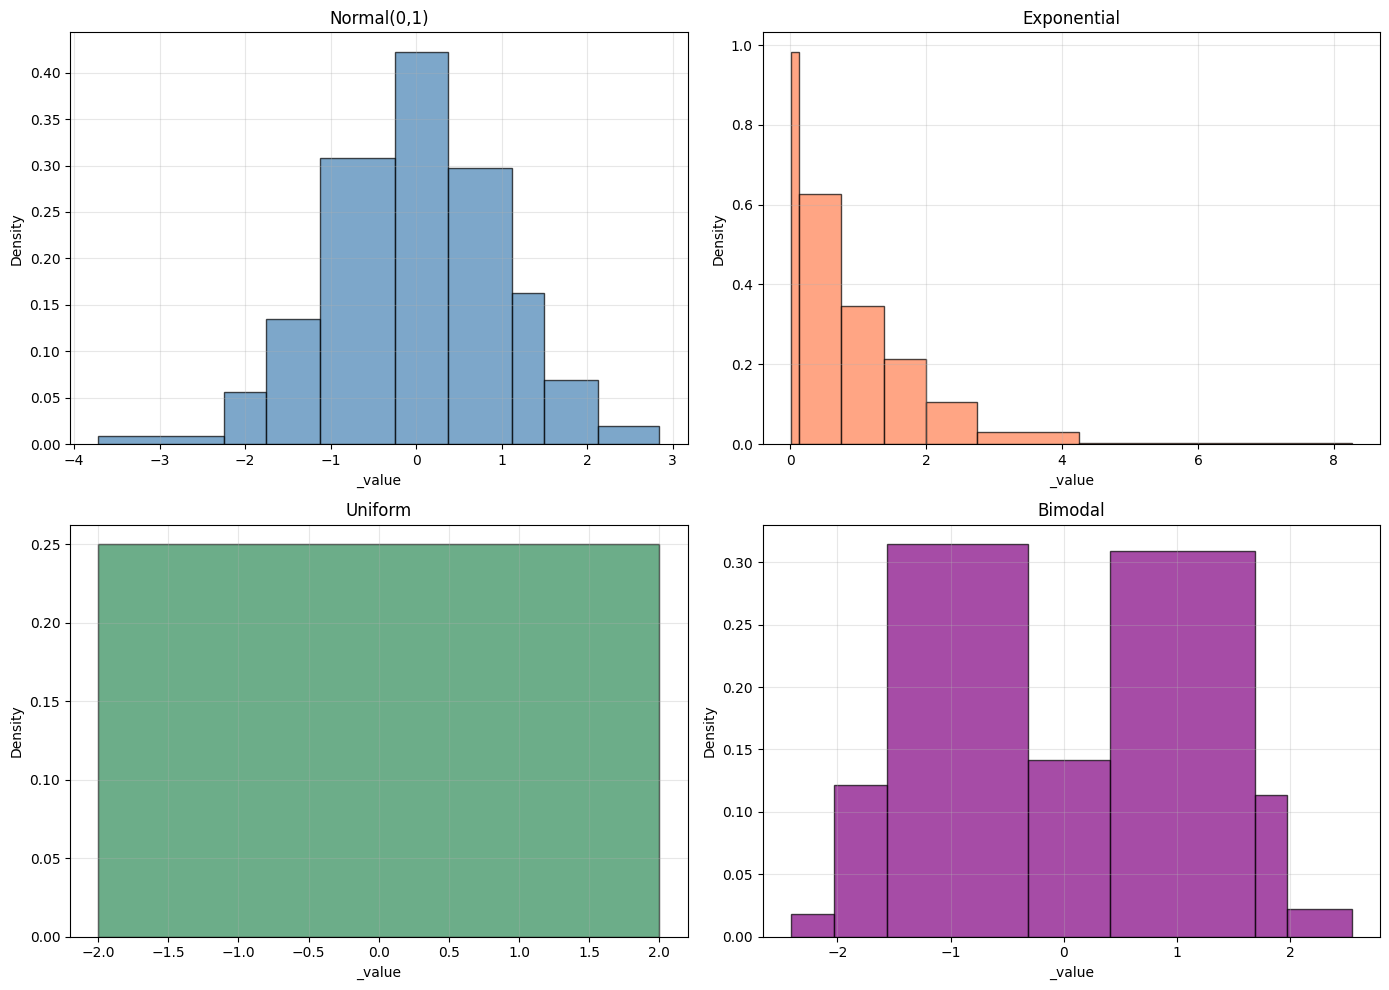

In [31]:
# Create multiple distributions
distributions = [
    ("Normal(0,1)", np.random.normal(0, 1, 1000)),
    ("Exponential", np.random.exponential(1, 1000)),
    ("Uniform", np.random.uniform(-2, 2, 1000)),
    (
        "Bimodal",
        np.concatenate([np.random.normal(-1, 0.5, 500), np.random.normal(1, 0.5, 500)]),
    ),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ["steelblue", "coral", "seagreen", "purple"]

for idx, (name, dist_data) in enumerate(distributions):
    histogram(
        x=dist_data,
        ax=axes[idx],
        title=name,
        color=colors[idx],
        alpha=0.7,
        edgecolor="black",
        linewidth=1,
    )
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Different Granularity Levels

Compare different granularity levels for binning.

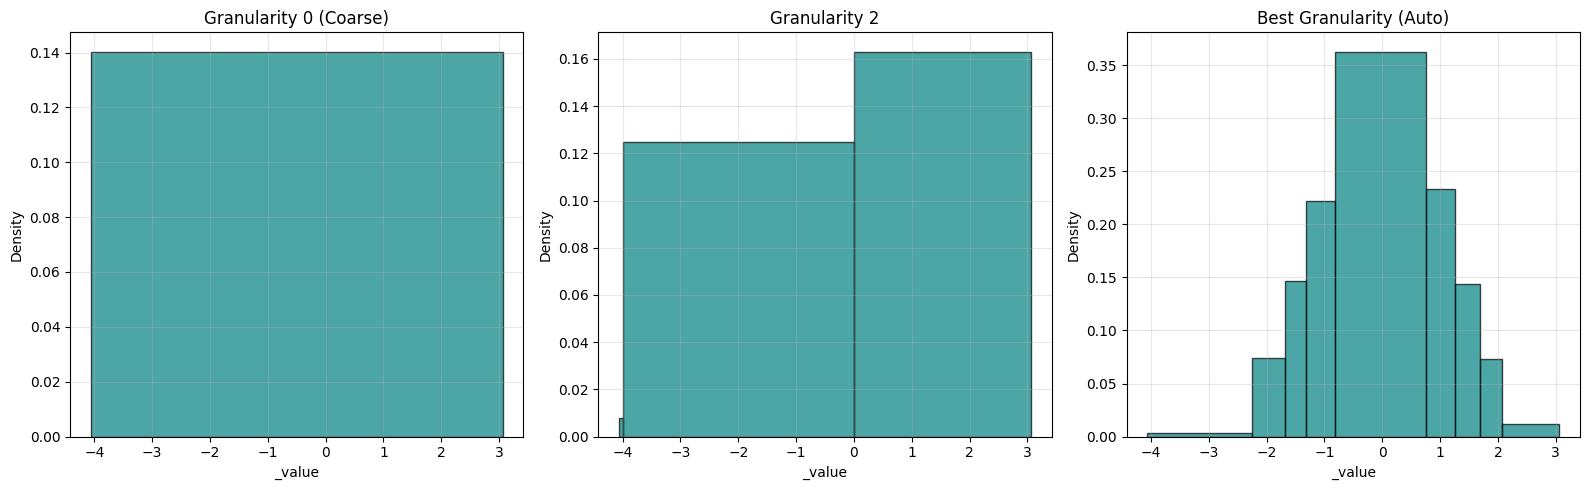

In [32]:
# Generate data
sample_data = np.random.normal(0, 1, 2000)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

granularities = [0, 2, "best"]
titles = ["Granularity 0 (Coarse)", "Granularity 2", "Best Granularity (Auto)"]

for ax, gran, title in zip(axes, granularities, titles):
    histogram(
        x=sample_data,
        ax=ax,
        granularity=gran,
        title=title,
        color="teal",
        alpha=0.7,
        edgecolor="black",
    )
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Custom Color Palettes

Use custom color palettes for grouped histograms.

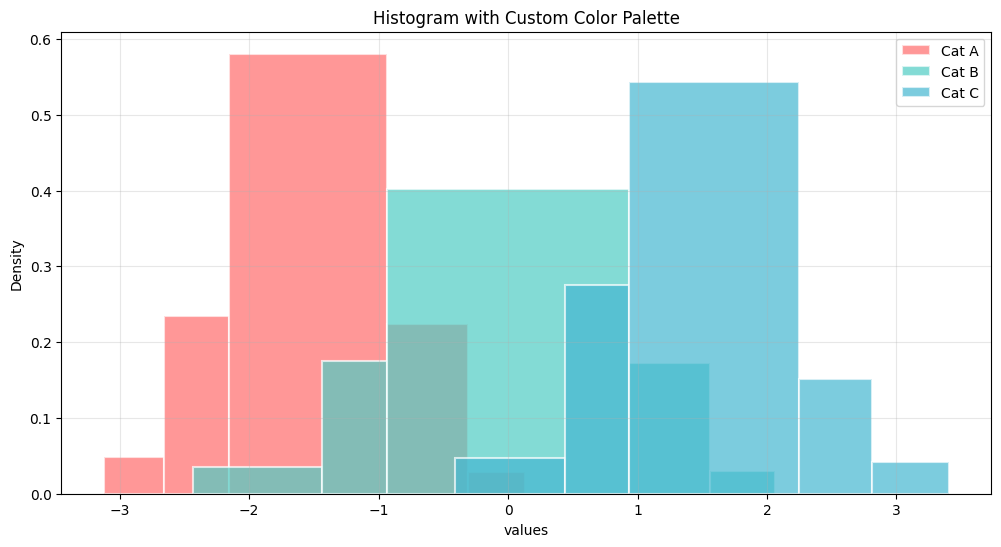

In [33]:
# Create grouped data
df_palette = pd.DataFrame(
    {
        "values": np.concatenate(
            [
                np.random.normal(-1.5, 0.6, 400),
                np.random.normal(0, 0.8, 400),
                np.random.normal(1.5, 0.6, 400),
            ]
        ),
        "category": ["Cat A"] * 400 + ["Cat B"] * 400 + ["Cat C"] * 400,
    }
)

# Custom color palette
custom_colors = ["#FF6B6B", "#4ECDC4", "#45B7D1"]

fig, ax = plt.subplots(figsize=(12, 6))
histogram(
    data=df_palette,
    x="values",
    hue="category",
    ax=ax,
    palette=custom_colors,
    title="Histogram with Custom Color Palette",
    alpha=0.7,
    edgecolor="white",
    linewidth=1.5,
)
plt.grid(alpha=0.3)
plt.show()

## 11. Side-by-Side Comparison: Vertical vs Horizontal

Compare the same data in both orientations.

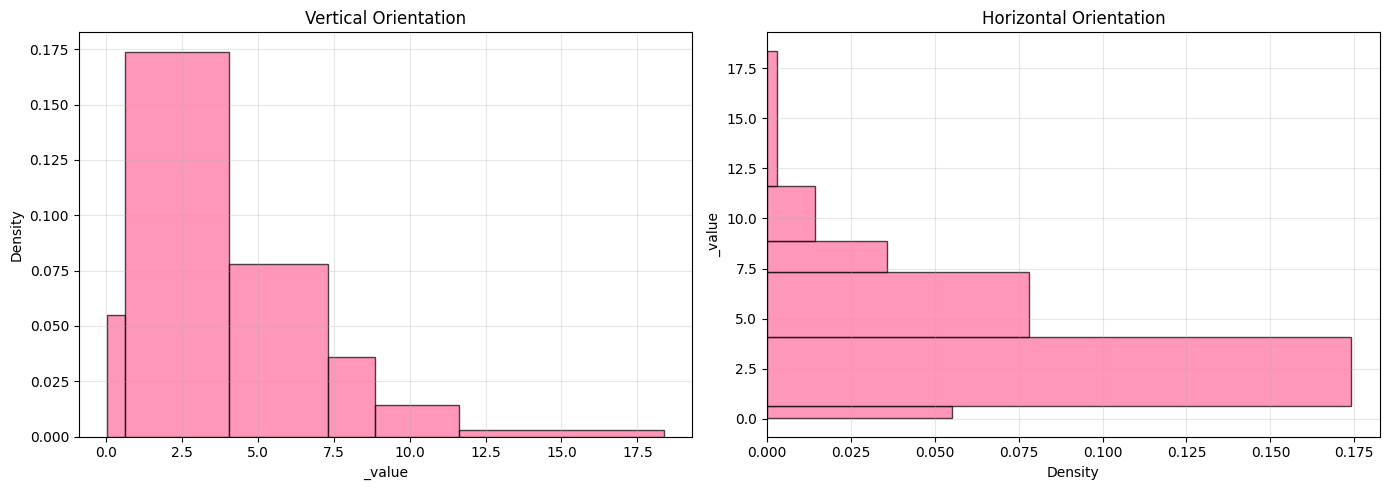

In [34]:
comparison_data = np.random.gamma(2, 2, 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Vertical
histogram(
    x=comparison_data,
    ax=ax1,
    orientation="vertical",
    title="Vertical Orientation",
    color="#FF6B9D",
    alpha=0.7,
    edgecolor="black",
)
ax1.grid(alpha=0.3)

# Horizontal
histogram(
    x=comparison_data,
    ax=ax2,
    orientation="horizontal",
    title="Horizontal Orientation",
    color="#FF6B9D",
    alpha=0.7,
    edgecolor="black",
)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 12. Working with Polars DataFrames

Demonstrate compatibility with Polars.

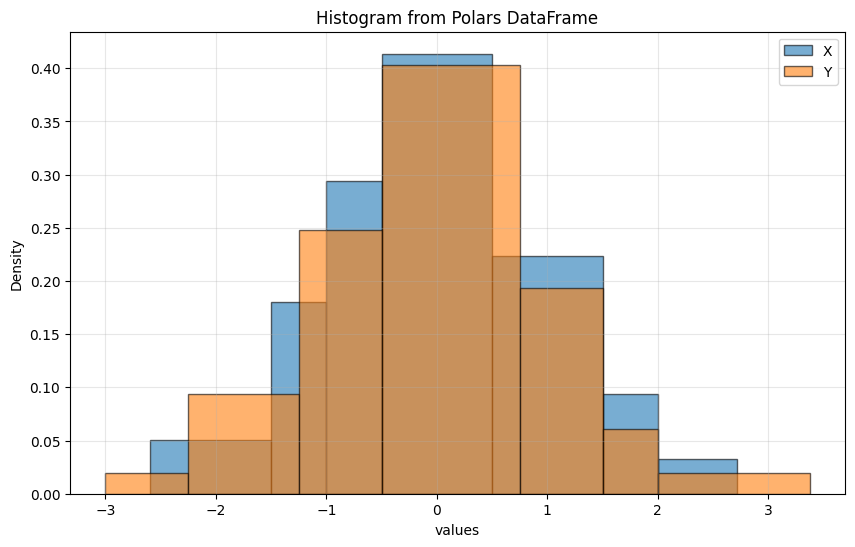

In [35]:
try:
    import polars as pl

    # Create Polars DataFrame
    df_polars = pl.DataFrame(
        {
            "values": np.random.normal(0, 1, 1000),
            "group": np.random.choice(["X", "Y"], 1000),
        }
    )

    fig, ax = plt.subplots(figsize=(10, 6))
    histogram(
        data=df_polars,
        x="values",
        hue="group",
        ax=ax,
        title="Histogram from Polars DataFrame",
        alpha=0.6,
        edgecolor="black",
    )
    plt.grid(alpha=0.3)
    plt.show()

except ImportError:
    print("Polars not installed. Install with: pip install polars")

## 13. Real-World Example: Analyzing Test Scores

A practical example analyzing test scores across different classes.

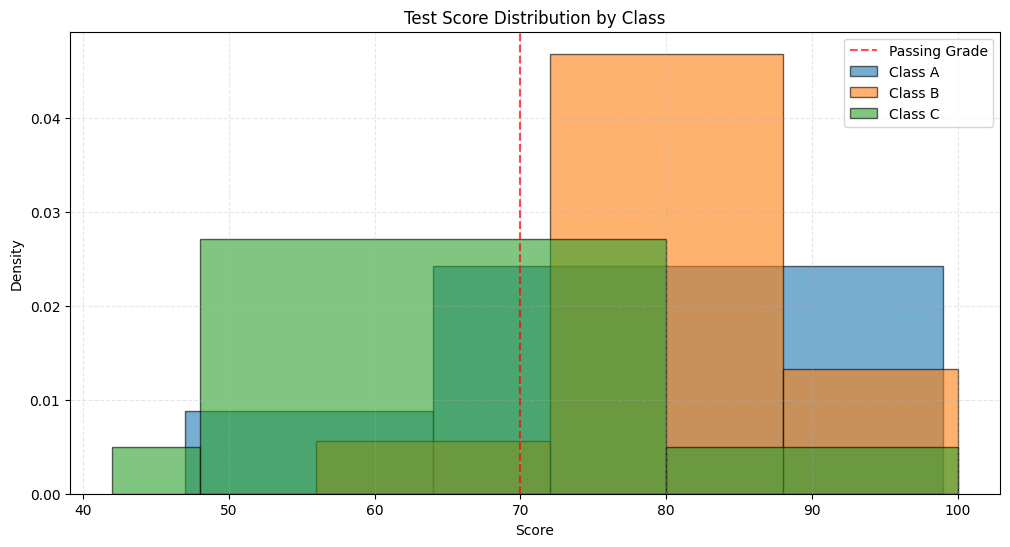


Summary Statistics:
         count       mean        std        min        25%        50%  \
class                                                                   
Class A  100.0  75.271091  11.339243  47.014109  66.672546  74.467303   
Class B  100.0  81.815851   7.728604  56.151560  77.610306  82.428197   
Class C  100.0  66.823389  11.585932  42.170079  58.552055  66.909651   

               75%         max  
class                           
Class A  84.833884   98.923653  
Class B  85.845564  100.000000  
Class C  75.098549  100.000000  


In [36]:
# Simulate test scores for different classes
np.random.seed(123)

test_scores = pd.DataFrame(
    {
        "score": np.concatenate(
            [
                np.random.normal(75, 10, 100),  # Class A
                np.random.normal(82, 8, 100),  # Class B
                np.random.normal(68, 12, 100),  # Class C
            ]
        ),
        "class": ["Class A"] * 100 + ["Class B"] * 100 + ["Class C"] * 100,
    }
)

# Clip scores to 0-100 range
test_scores["score"] = test_scores["score"].clip(0, 100)

fig, ax = plt.subplots(figsize=(12, 6))
histogram(
    data=test_scores,
    x="score",
    hue="class",
    ax=ax,
    title="Test Score Distribution by Class",
    xlabel="Score",
    ylabel="Density",
    alpha=0.6,
    edgecolor="black",
    linewidth=1,
)
plt.grid(alpha=0.3, linestyle="--")
plt.axvline(x=70, color="red", linestyle="--", alpha=0.7, label="Passing Grade")
plt.legend()
plt.show()

print("\nSummary Statistics:")
print(test_scores.groupby("class")["score"].describe())

## Summary

This notebook demonstrated:

### Histogram Examples (1-13):
1. **Basic histograms** with automatic optimal binning
2. **Orientation options** (vertical and horizontal)
3. **Cumulative distributions** (using the `cumulative` function)
4. **Custom styling** (colors, transparency, edges)
5. **DataFrame integration** (Pandas and Polars)
6. **Grouped histograms** using the `hue` parameter
7. **Subplot layouts** for comparing distributions
8. **Granularity control** for different levels of detail
9. **Custom color palettes**
10. **Real-world applications**

### Cumulative Distribution Examples (14-19):
11. **Basic CDF plots** showing cumulative probability
12. **Comparing distributions** - differences are clearer with CDF
13. **Horizontal orientation** for cumulative plots
14. **Markers and styling** for emphasis
15. **Side-by-side comparison** of histogram vs CDF
16. **Percentile analysis** using CDF for real-world data

The matplotlib `histogram` and `cumulative` functions integrate seamlessly with matplotlib's ecosystem while providing Khisto's powerful automatic binning algorithm.

# Cumulative Distribution Examples

The following examples demonstrate the `cumulative` function for creating CDF plots.

## 14. Basic Cumulative Distribution

A simple CDF showing the probability that a value is less than or equal to x.

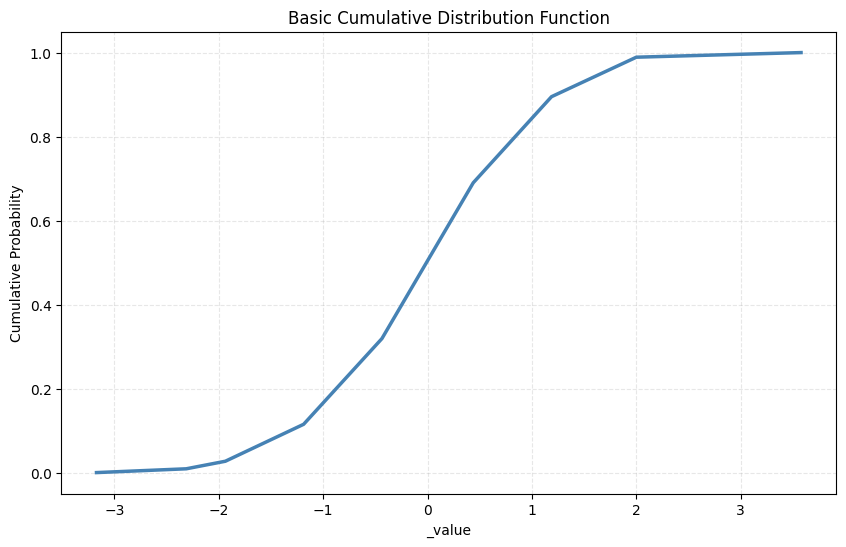

In [37]:
# Generate sample data
cdf_data = np.random.normal(0, 1, 1000)

# Create cumulative distribution plot
fig, ax = plt.subplots(figsize=(10, 6))
cumulative(
    x=cdf_data,
    ax=ax,
    title="Basic Cumulative Distribution Function",
    color="steelblue",
    linewidth=2.5,
)
plt.grid(alpha=0.3, linestyle="--")
plt.show()

## 15. Comparing Multiple Distributions with CDF

Use CDF to compare different distributions - differences are often clearer than with histograms.

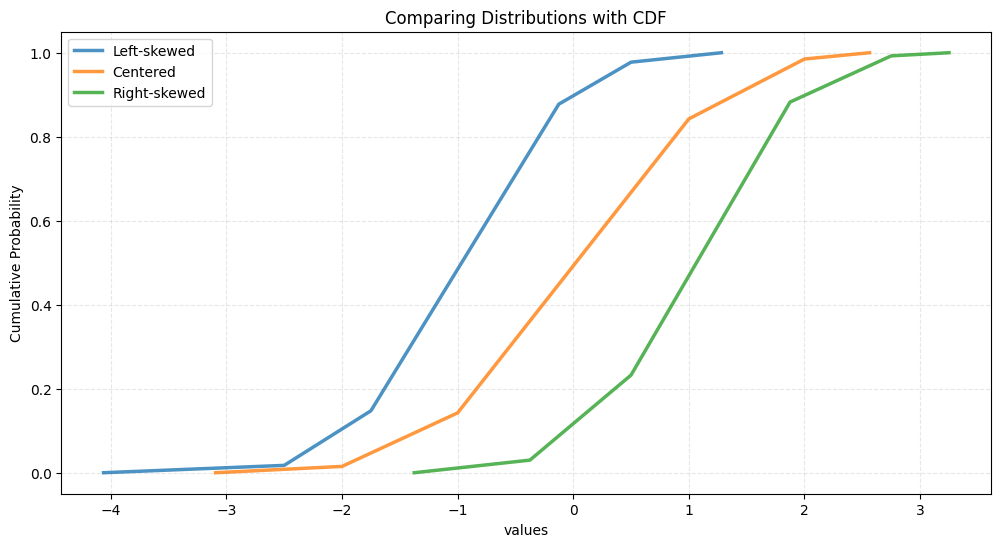

In [38]:
# Create DataFrame with different distributions
df_cdf = pd.DataFrame(
    {
        "values": np.concatenate(
            [
                np.random.normal(-1, 0.8, 400),
                np.random.normal(0, 1, 400),
                np.random.normal(1, 0.8, 400),
            ]
        ),
        "distribution": ["Left-skewed"] * 400
        + ["Centered"] * 400
        + ["Right-skewed"] * 400,
    }
)

fig, ax = plt.subplots(figsize=(12, 6))
cumulative(
    data=df_cdf,
    x="values",
    hue="distribution",
    ax=ax,
    title="Comparing Distributions with CDF",
    linewidth=2.5,
    alpha=0.8,
)
plt.grid(alpha=0.3, linestyle="--")
plt.legend(loc="upper left")
plt.show()

## 16. Horizontal CDF Plot

CDF can also be displayed in horizontal orientation.

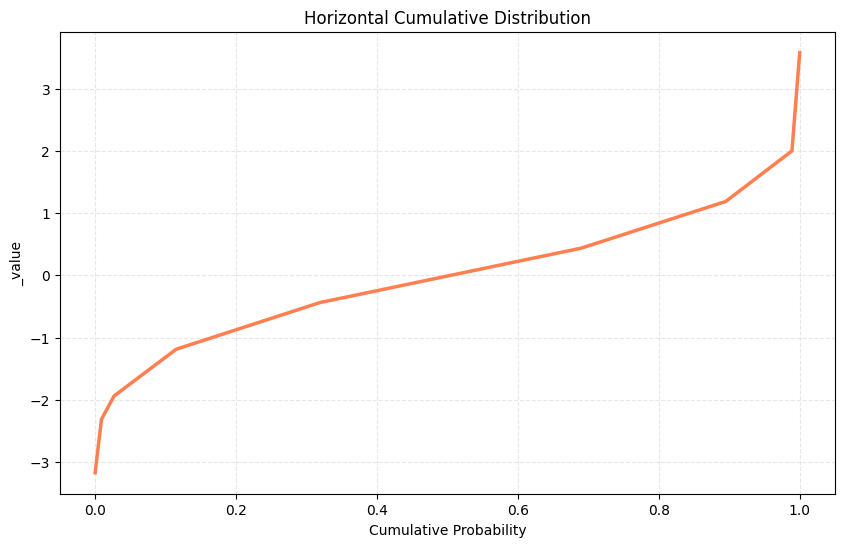

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))
cumulative(
    x=cdf_data,
    ax=ax,
    orientation="horizontal",
    title="Horizontal Cumulative Distribution",
    color="coral",
    linewidth=2.5,
)
plt.grid(alpha=0.3, linestyle="--")
plt.show()

## 17. CDF with Markers

Add markers to highlight specific points on the cumulative distribution.

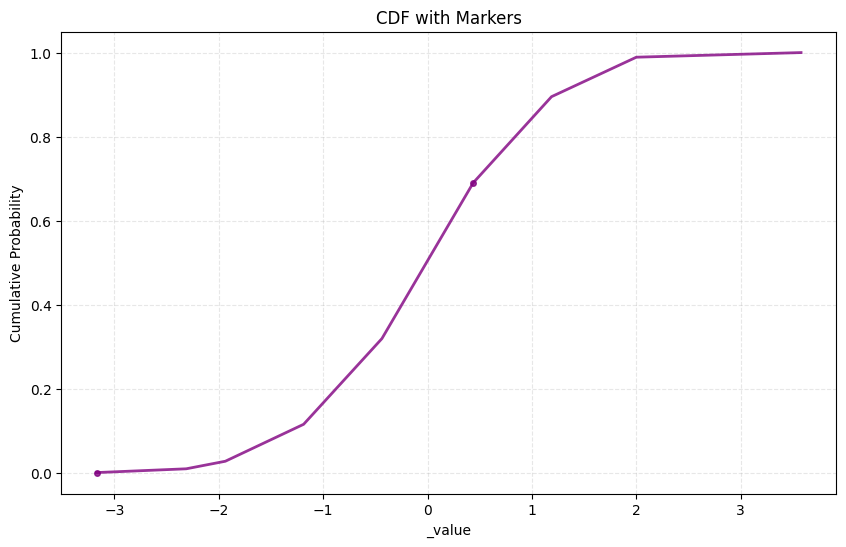

In [40]:
fig, ax = plt.subplots(figsize=(10, 6))
cumulative(
    x=cdf_data,
    ax=ax,
    title="CDF with Markers",
    color="purple",
    linewidth=2,
    marker="o",
    markersize=4,
    markevery=5,
    alpha=0.8,
)
plt.grid(alpha=0.3, linestyle="--")
plt.show()

## 18. Side-by-Side: Histogram vs CDF

Compare the same data shown as both a histogram and cumulative distribution.

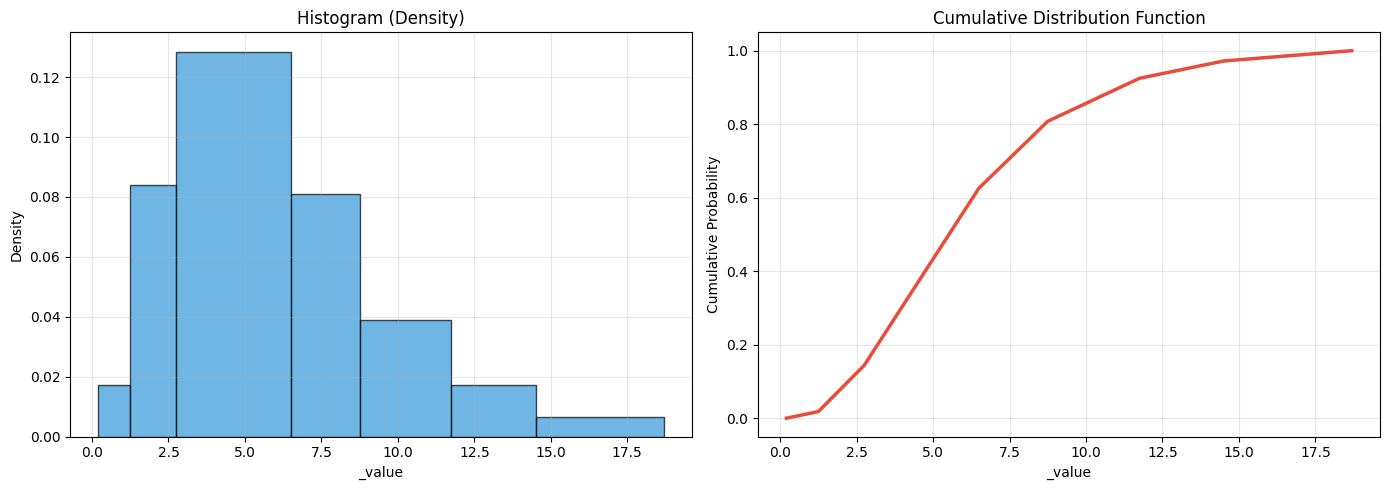

In [41]:
comparison_data = np.random.gamma(3, 2, 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
histogram(
    x=comparison_data,
    ax=ax1,
    title="Histogram (Density)",
    color="#3498db",
    alpha=0.7,
    edgecolor="black",
)
ax1.grid(alpha=0.3)

# Cumulative Distribution
cumulative(
    x=comparison_data,
    ax=ax2,
    title="Cumulative Distribution Function",
    color="#e74c3c",
    linewidth=2.5,
)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 19. Real-World Example: Test Score Analysis with CDF

Use CDF to analyze test scores and identify percentiles.

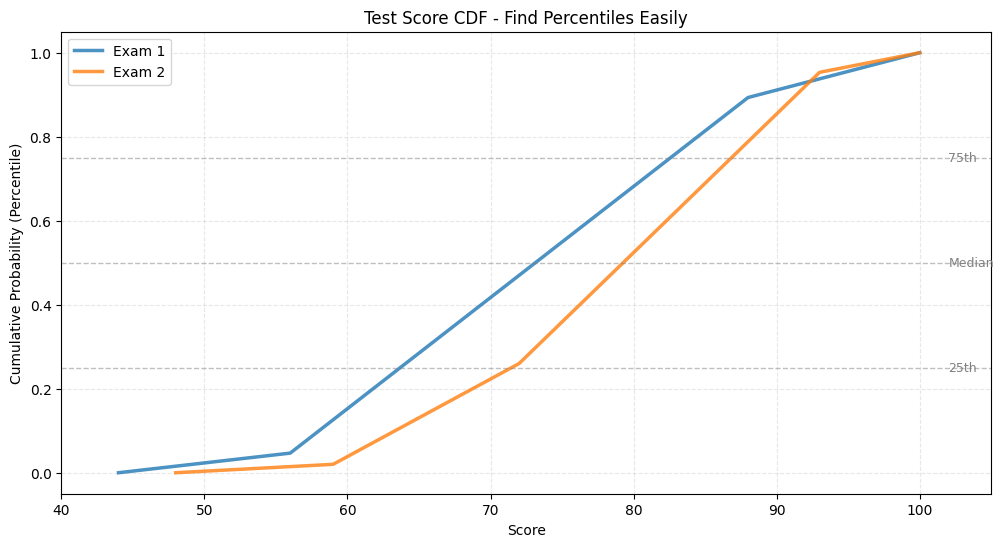


How to read the CDF:
- The y-axis shows the percentage of students scoring at or below a given score
- For example, if the line crosses y=0.5 at x=75, then 50% of students scored 75 or below
- The steeper the curve, the more students clustered around that score range


In [42]:
# Simulate test scores
np.random.seed(456)

exam_scores = pd.DataFrame(
    {
        "score": np.concatenate(
            [
                np.random.normal(72, 12, 150),  # Exam 1
                np.random.normal(78, 10, 150),  # Exam 2
            ]
        ),
        "exam": ["Exam 1"] * 150 + ["Exam 2"] * 150,
    }
)

# Clip scores to 0-100 range
exam_scores["score"] = exam_scores["score"].clip(0, 100)

fig, ax = plt.subplots(figsize=(12, 6))
cumulative(
    data=exam_scores,
    x="score",
    hue="exam",
    ax=ax,
    title="Test Score CDF - Find Percentiles Easily",
    xlabel="Score",
    ylabel="Cumulative Probability (Percentile)",
    linewidth=2.5,
    alpha=0.8,
)

# Add reference lines for common percentiles
for percentile, label in [(0.25, "25th"), (0.5, "Median"), (0.75, "75th")]:
    ax.axhline(y=percentile, color="gray", linestyle="--", alpha=0.5, linewidth=1)
    ax.text(102, percentile, label, va="center", fontsize=9, color="gray")

plt.grid(alpha=0.3, linestyle="--")
plt.legend()
plt.xlim(40, 105)
plt.show()

print("\nHow to read the CDF:")
print("- The y-axis shows the percentage of students scoring at or below a given score")
print(
    "- For example, if the line crosses y=0.5 at x=75, then 50% of students scored 75 or below"
)
print("- The steeper the curve, the more students clustered around that score range")

Number of containers: 2
Container 0: 2 bars, label=A
Container 1: 1 bars, label=B


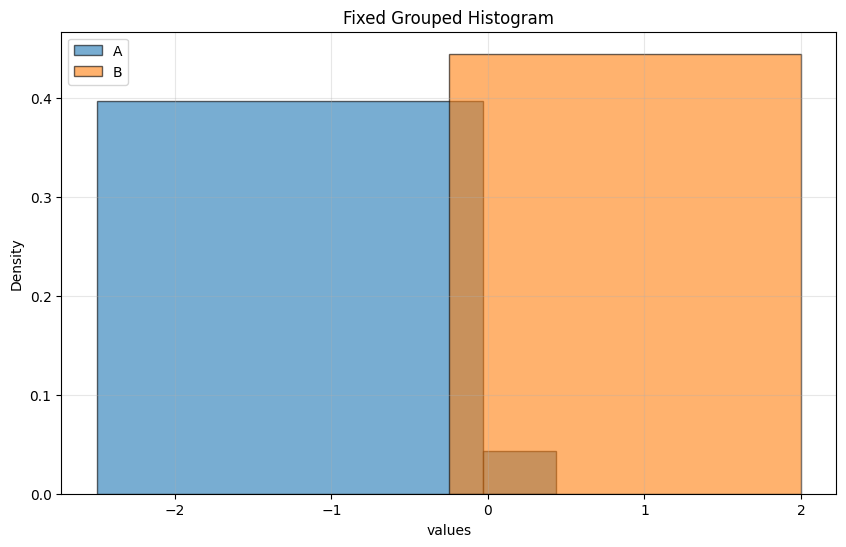

In [43]:
# Test the fix
test_df = pd.DataFrame(
    {
        "values": np.concatenate(
            [np.random.normal(-1, 0.5, 50), np.random.normal(1, 0.5, 50)]
        ),
        "group": ["A"] * 50 + ["B"] * 50,
    }
)

fig, ax = plt.subplots(figsize=(10, 6))
containers = histogram(
    data=test_df,
    x="values",
    hue="group",
    ax=ax,
    title="Fixed Grouped Histogram",
    alpha=0.6,
    edgecolor="black",
)
plt.grid(alpha=0.3)
print(f"Number of containers: {len(containers) if isinstance(containers, list) else 1}")
if isinstance(containers, list):
    for i, c in enumerate(containers):
        print(f"Container {i}: {len(c.patches)} bars, label={c.get_label()}")
plt.show()